<a href="https://colab.research.google.com/github/MDKhairuzzamanRakib/Thesis/blob/main/02_risk_assessment_Smartphone_MobileUsage_DRIVE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 3 & 6: Risk Assessment (Smartphone Addiction / Mobile Usage)

## Step 0: Mount Drive and set your data folder pathEdit `DATA_DIR` below to match wherever you uploaded the CSVs in your Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/Thesis/NoteBook2'

import os
print("Files found in DATA_DIR:")
for f in sorted(os.listdir(DATA_DIR)):
    print(" -", f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files found in DATA_DIR:
 - mobile_usage_test.csv
 - mobile_usage_train.csv
 - mobile_usage_val.csv
 - smartphone_test.csv
 - smartphone_train.csv
 - smartphone_val.csv


In [2]:
!pip install -q xgboost shap imbalanced-learn scikit-learn

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

## Step 1: Load Smartphone Addiction dataset from Drive + encode categorical columns

In [4]:
train = pd.read_csv(f'{DATA_DIR}/smartphone_train.csv')
val = pd.read_csv(f'{DATA_DIR}/smartphone_val.csv')
test = pd.read_csv(f'{DATA_DIR}/smartphone_test.csv')
print(train.dtypes)

age                          int64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
gender_Male                   bool
gender_Other                  bool
dtype: object


In [5]:
# Encode any text/categorical columns to numbers (SMOTE and XGBoost need numeric input)cat_cols = [c for c in train.columns if train[c].dtype == 'object']print('Categorical columns to encode:', cat_cols)from sklearn.preprocessing import LabelEncoderfor col in cat_cols:    le = LabelEncoder()    train[col] = le.fit_transform(train[col].astype(str))    val[col] = val[col].astype(str).map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)    test[col] = test[col].astype(str).map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)print(train.dtypes)  # confirm everything is now numeric

In [6]:
cat_cols = [c for c in train.columns if train[c].dtype == 'object']
print('Categorical columns to encode:', cat_cols)

from sklearn.preprocessing import LabelEncoder
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    val[col] = val[col].astype(str).map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    test[col] = test[col].astype(str).map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

print(train.dtypes)

Categorical columns to encode: ['stress_level', 'academic_work_impact', 'addiction_level']
age                          int64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                 int64
academic_work_impact         int64
addiction_level              int64
addicted_label               int64
gender_Male                   bool
gender_Other                  bool
dtype: object


In [7]:
target = 'addicted_label'
drop_cols = ['addicted_label', 'addiction_level']
feature_cols = [c for c in train.columns if c not in drop_cols]

Xtr, ytr = train[feature_cols], train[target]
Xval, yval = val[feature_cols], val[target]
Xte, yte = test[feature_cols], test[target]

print(feature_cols)
print(Xtr.shape, Xval.shape, Xte.shape)

['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'gender_Male', 'gender_Other']
(5250, 13) (1125, 13) (1125, 13)


## Step 2: Handle class imbalance with SMOTE (training set only)

In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)
print('Before:', ytr.value_counts().to_dict())
print('After:', ytr_res.value_counts().to_dict())

Before: {1: 3716, 0: 1534}
After: {0: 3716, 1: 3716}


## Step 3: Baseline — XGBoost

In [9]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric='logloss', random_state=42
)
xgb_clf.fit(Xtr_res, ytr_res)

preds = xgb_clf.predict(Xte)
probs = xgb_clf.predict_proba(Xte)[:,1]
print(classification_report(yte, preds))
print('ROC-AUC:', roc_auc_score(yte, probs))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       329
           1       0.97      0.93      0.95       796

    accuracy                           0.93      1125
   macro avg       0.91      0.93      0.92      1125
weighted avg       0.93      0.93      0.93      1125

ROC-AUC: 0.9882161567717005


## Step 4: Deep learning option — MLP (to match your 'deep learning framework' framing)

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xtr_scaled = scaler.fit_transform(Xtr_res)
Xte_scaled = scaler.transform(Xte)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Xtr_t = torch.tensor(Xtr_scaled, dtype=torch.float32)
ytr_t = torch.tensor(ytr_res.values, dtype=torch.float32)
Xte_t = torch.tensor(Xte_scaled, dtype=torch.float32)
yte_t = torch.tensor(yte.values, dtype=torch.float32)

train_ds = TensorDataset(Xtr_t, ytr_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = MLP(Xtr_t.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(30):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}: loss={total_loss/len(train_loader):.4f}')

Epoch 5: loss=0.1645
Epoch 10: loss=0.1371
Epoch 15: loss=0.1217
Epoch 20: loss=0.1157
Epoch 25: loss=0.1100
Epoch 30: loss=0.1001


In [11]:
model.eval()
with torch.no_grad():
    logits = model(Xte_t.to(device))
    probs_mlp = torch.sigmoid(logits).cpu().numpy()
    preds_mlp = (probs_mlp > 0.5).astype(int)

print(classification_report(yte, preds_mlp))
print('ROC-AUC:', roc_auc_score(yte, probs_mlp))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       329
           1       0.98      0.93      0.95       796

    accuracy                           0.94      1125
   macro avg       0.91      0.94      0.92      1125
weighted avg       0.94      0.94      0.94      1125

ROC-AUC: 0.9867765881077117


## Step 5: Explainability — SHAP for XGBoost

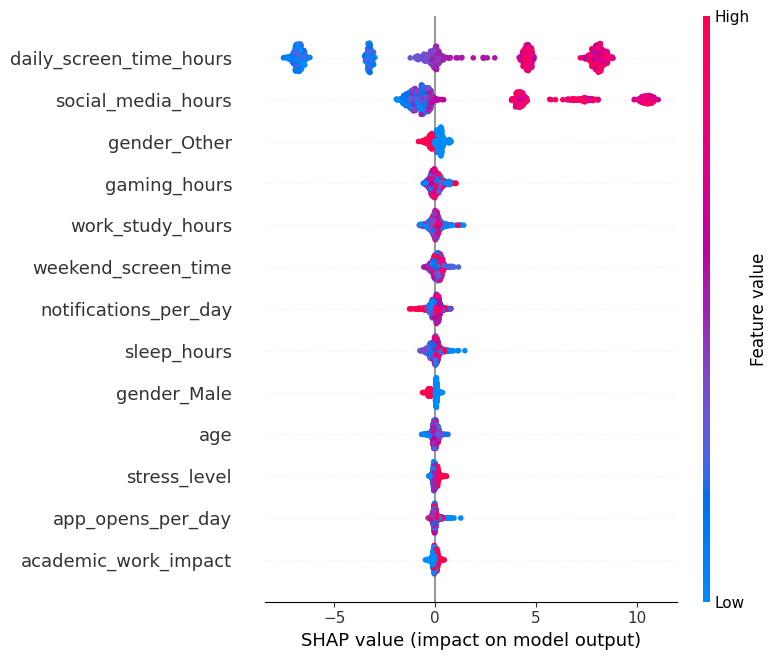

In [15]:
import shap

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(Xte)

shap.summary_plot(shap_values, Xte, feature_names=feature_cols)

Predicted risk probability: 0.9999676


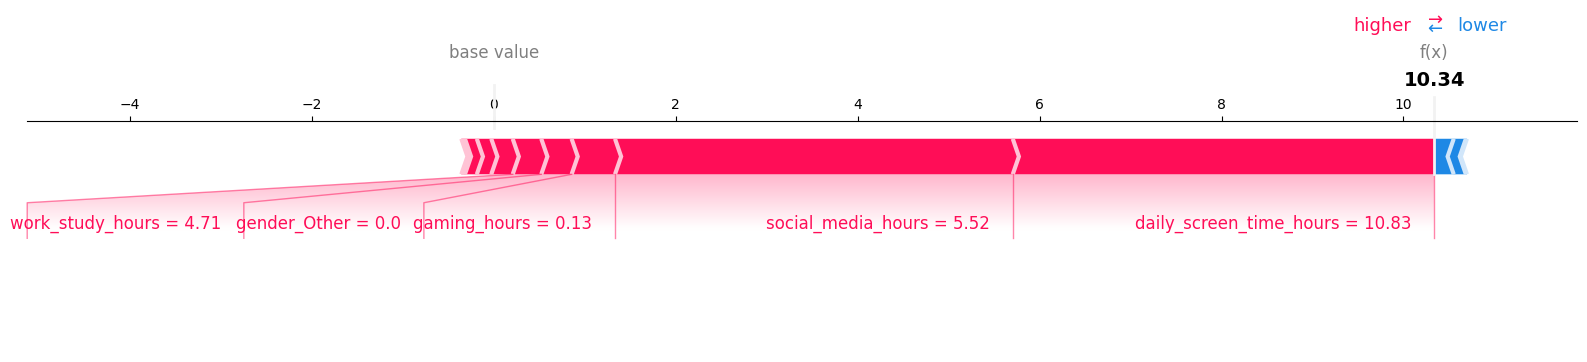

In [16]:
idx = int(np.argmax(probs))
print('Predicted risk probability:', probs[idx])
shap.force_plot(explainer.expected_value, shap_values[idx], Xte.iloc[idx], matplotlib=True)

## Step 6: Convert probability to Risk Tiers (Low / Medium / High)

In [17]:
def risk_tier(p):
    if p < 0.33: return 'Low'
    elif p < 0.66: return 'Medium'
    else: return 'High'

test_results = test.copy()
test_results['risk_probability'] = probs
test_results['risk_tier'] = test_results['risk_probability'].apply(risk_tier)
print(test_results['risk_tier'].value_counts())
test_results[['risk_probability','risk_tier']].head(10)

risk_tier
High      746
Low       337
Medium     42
Name: count, dtype: int64


,risk_probability,risk_tier
0,0.000582,Low
1,0.000243,Low
2,0.999498,High
3,0.999770,High
4,0.913989,High
5,0.000136,Low
6,0.999564,High
7,0.999627,High
8,0.999943,High
9,0.999400,High


## Step 7: Save results back to Drive

In [18]:
SAVE_DIR = '/content/drive/MyDrive/Thesis/Models/Results'
import os
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), f'{SAVE_DIR}/hatexplain_hybrid_model.pt')
print('Saved to', f'{SAVE_DIR}/hatexplain_hybrid_model.pt')

Saved to /content/drive/MyDrive/Thesis/Models/Results/hatexplain_hybrid_model.pt
